In [63]:
#Importing Dependencies
import numpy as np
import pandas as pd
from pandas import read_csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection, metrics
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve, StratifiedKFold


import warnings
warnings.filterwarnings("ignore")


In [ ]:

# DATA PREPROCESSING


In [ ]:
# importing dataset to a pandas Dataframe
#dataset= pd.read_csv("/Users/mishr/OneDrive/Desktop/CSC215_AI/diabetes.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

dataset = read_csv('diabetes.csv')



NameError: name 'pd' is not defined

In [ ]:
print(dataset.describe(), "\n")
print(dataset.info(), "\n")

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000  768.000000
mean      3.845052  120.894531      69.105469      20.536458   79.799479   31.992578                  0.471876   33.240885    0.348958
std       3.369578   31.972618      19.355807      15.952218  115.244002    7.884160                  0.331329   11.760232    0.476951
min       0.000000    0.000000       0.000000       0.000000    0.000000    0.000000                  0.078000   21.000000    0.000000
25%       1.000000   99.000000      62.000000       0.000000    0.000000   27.300000                  0.243750   24.000000    0.000000
50%       3.000000  117.000000      72.000000      23.000000   30.500000   32.000000                  0.372500   29.000000    0.000000
75%       6.000000  140.250000      80.000000      32.0

In [66]:
# Print First 10 and last 10 rows
print(dataset.head(10))
print(dataset.tail(10), "\n")

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.288   33        1
5            5      116             74              0        0  25.6                     0.201   30        0
6            3       78             50             32       88  31.0                     0.248   26        1
7           10      115              0              0        0  35.3                     0.134   29        0
8            2     

In [67]:
# All features are numeric and there are 0 null's
print(dataset.describe(), "\n")
print(dataset.info(), "\n")

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000  768.000000
mean      3.845052  120.894531      69.105469      20.536458   79.799479   31.992578                  0.471876   33.240885    0.348958
std       3.369578   31.972618      19.355807      15.952218  115.244002    7.884160                  0.331329   11.760232    0.476951
min       0.000000    0.000000       0.000000       0.000000    0.000000    0.000000                  0.078000   21.000000    0.000000
25%       1.000000   99.000000      62.000000       0.000000    0.000000   27.300000                  0.243750   24.000000    0.000000
50%       3.000000  117.000000      72.000000      23.000000   30.500000   32.000000                  0.372500   29.000000    0.000000
75%       6.000000  140.250000      80.000000      32.0

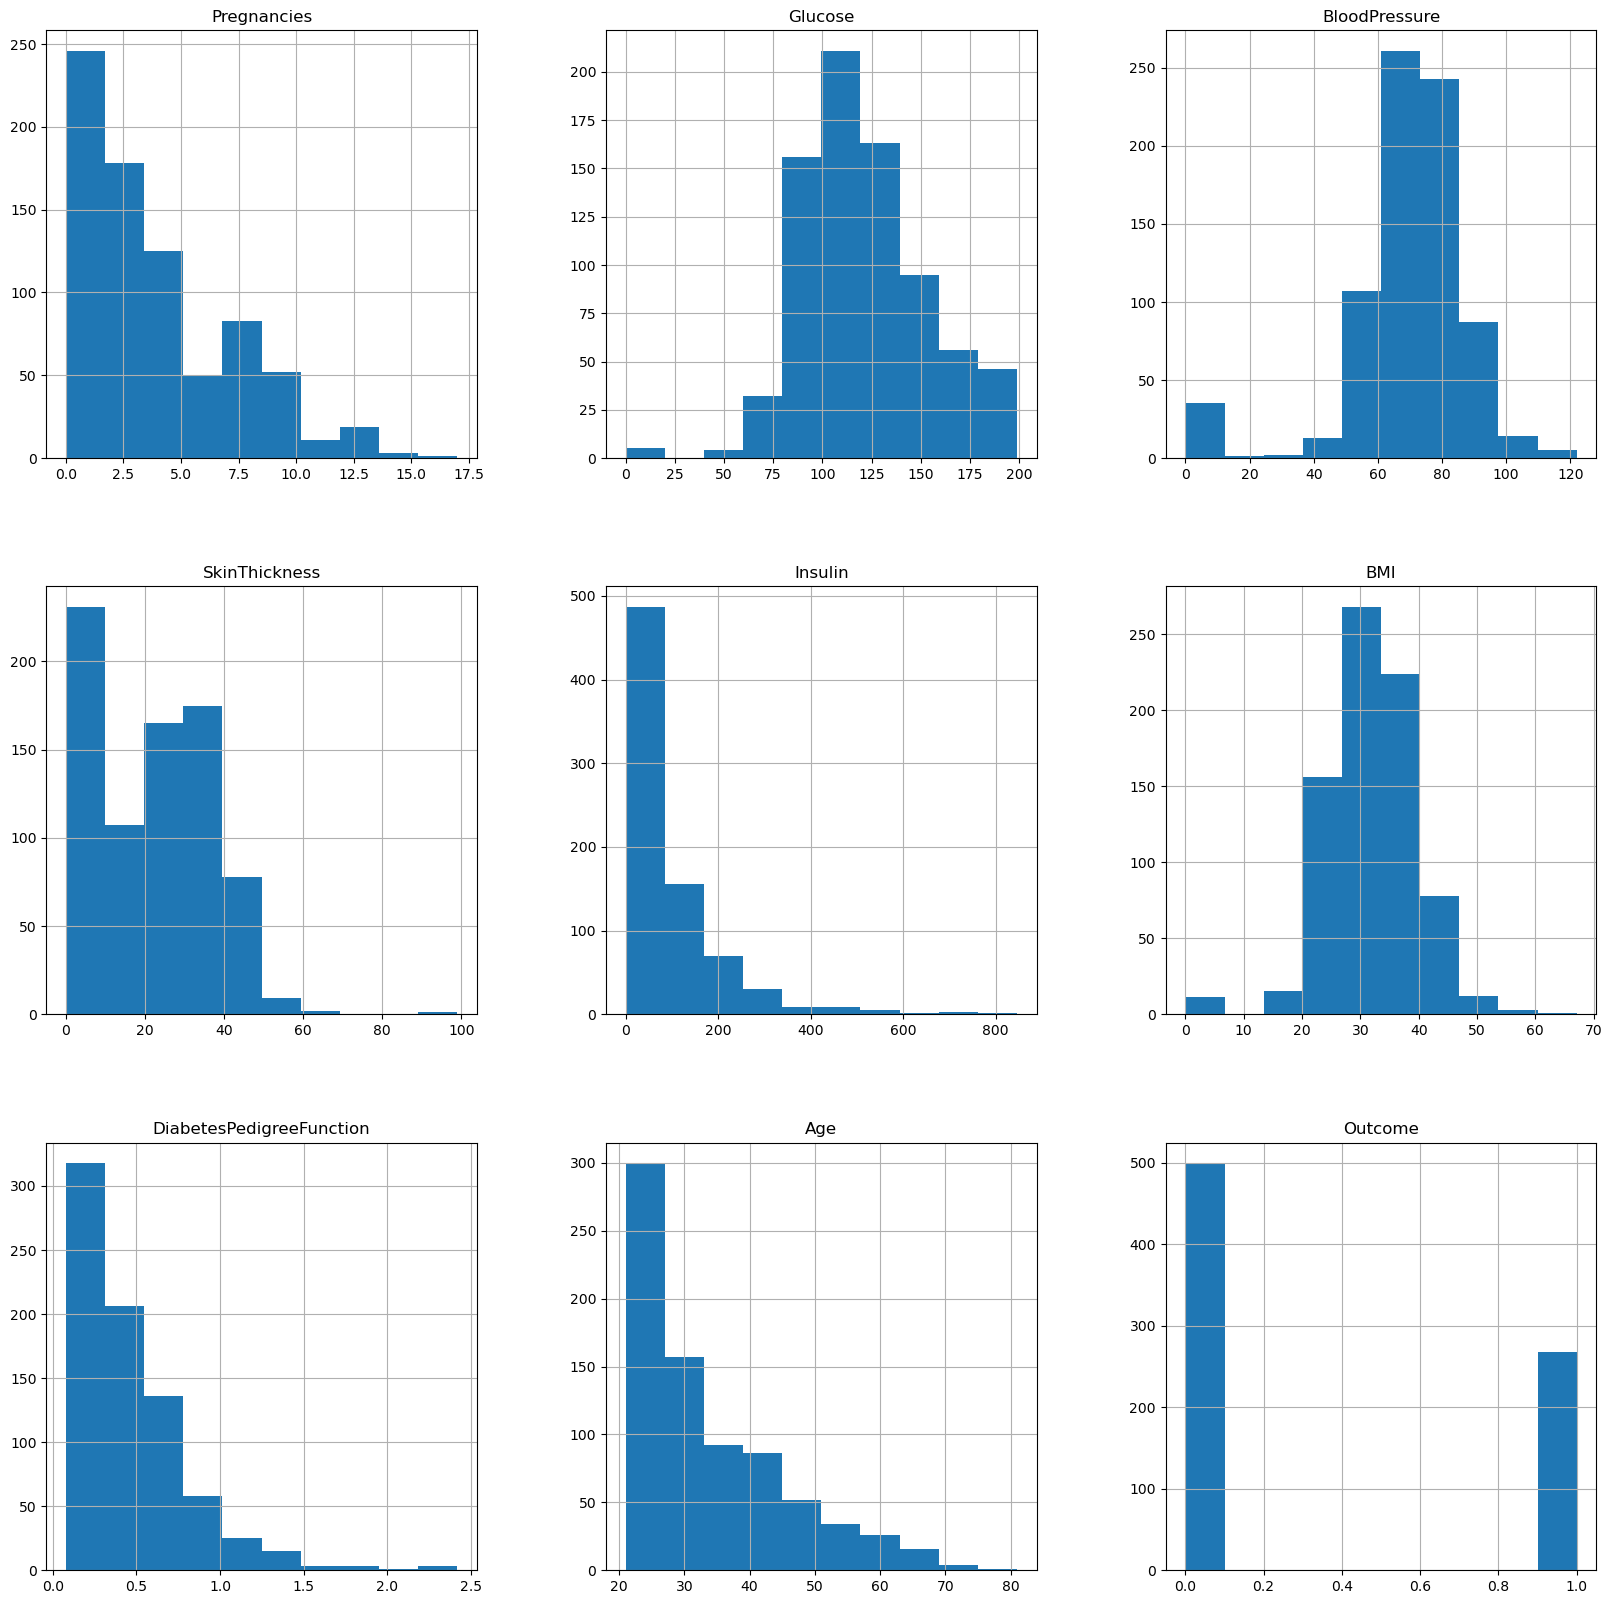

# of Rows, # of Columns:  (768, 8)

Column Name           # of 0 Values

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [68]:
# Lot of 0 values for SkinThickness and Insulin, some for glucose, blood pressure, and BMI as well
p = dataset.hist(figsize = (20,20))
plt.show()
dataset2 = dataset.iloc[:, :-1]
print("# of Rows, # of Columns: ",dataset2.shape)
print("\nColumn Name           # of 0 Values\n")
print((dataset2[:] == 0).sum())


In [69]:
# Transform 0's into NaN's (excluding pregnancies)
diabetes_data_copy = dataset.copy(deep = True)
diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)


In [70]:
## showing the count of Nans
print(diabetes_data_copy.isnull().sum())
print(diabetes_data_copy.info(), "\n")

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null  

In [71]:
# Fill-up missing values with KNNImputer
KNN_imputer = KNNImputer(n_neighbors=5)
output = KNN_imputer.fit_transform(diabetes_data_copy)

dataset = pd.DataFrame(output, columns=KNN_imputer.get_feature_names_out())  # Transfrom numpy-array 2 pandas-dataframe
print(dataset.describe(), "\n")
print(dataset.info())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000  768.000000
mean      3.845052  121.598177      72.371354      29.114583  153.180208   32.427344                  0.471876   33.240885    0.348958
std       3.369578   30.496543      12.206417       9.424100   98.385308    6.886588                  0.331329   11.760232    0.476951
min       0.000000   44.000000      24.000000       7.000000   14.000000   18.200000                  0.078000   21.000000    0.000000
25%       1.000000   99.000000      64.000000      23.000000   87.900000   27.500000                  0.243750   24.000000    0.000000
50%       3.000000  117.000000      72.000000      29.000000  133.700000   32.090000                  0.372500   29.000000    0.000000
75%       6.000000  140.250000      80.000000      35.0

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000  768.000000
mean      3.845052  121.598177      72.371354      29.114583  153.180208   32.427344                  0.471876   33.240885    0.348958
std       3.369578   30.496543      12.206417       9.424100   98.385308    6.886588                  0.331329   11.760232    0.476951
min       0.000000   44.000000      24.000000       7.000000   14.000000   18.200000                  0.078000   21.000000    0.000000
25%       1.000000   99.000000      64.000000      23.000000   87.900000   27.500000                  0.243750   24.000000    0.000000
50%       3.000000  117.000000      72.000000      29.000000  133.700000   32.090000                  0.372500   29.000000    0.000000
75%       6.000000  140.250000      80.000000      35.0

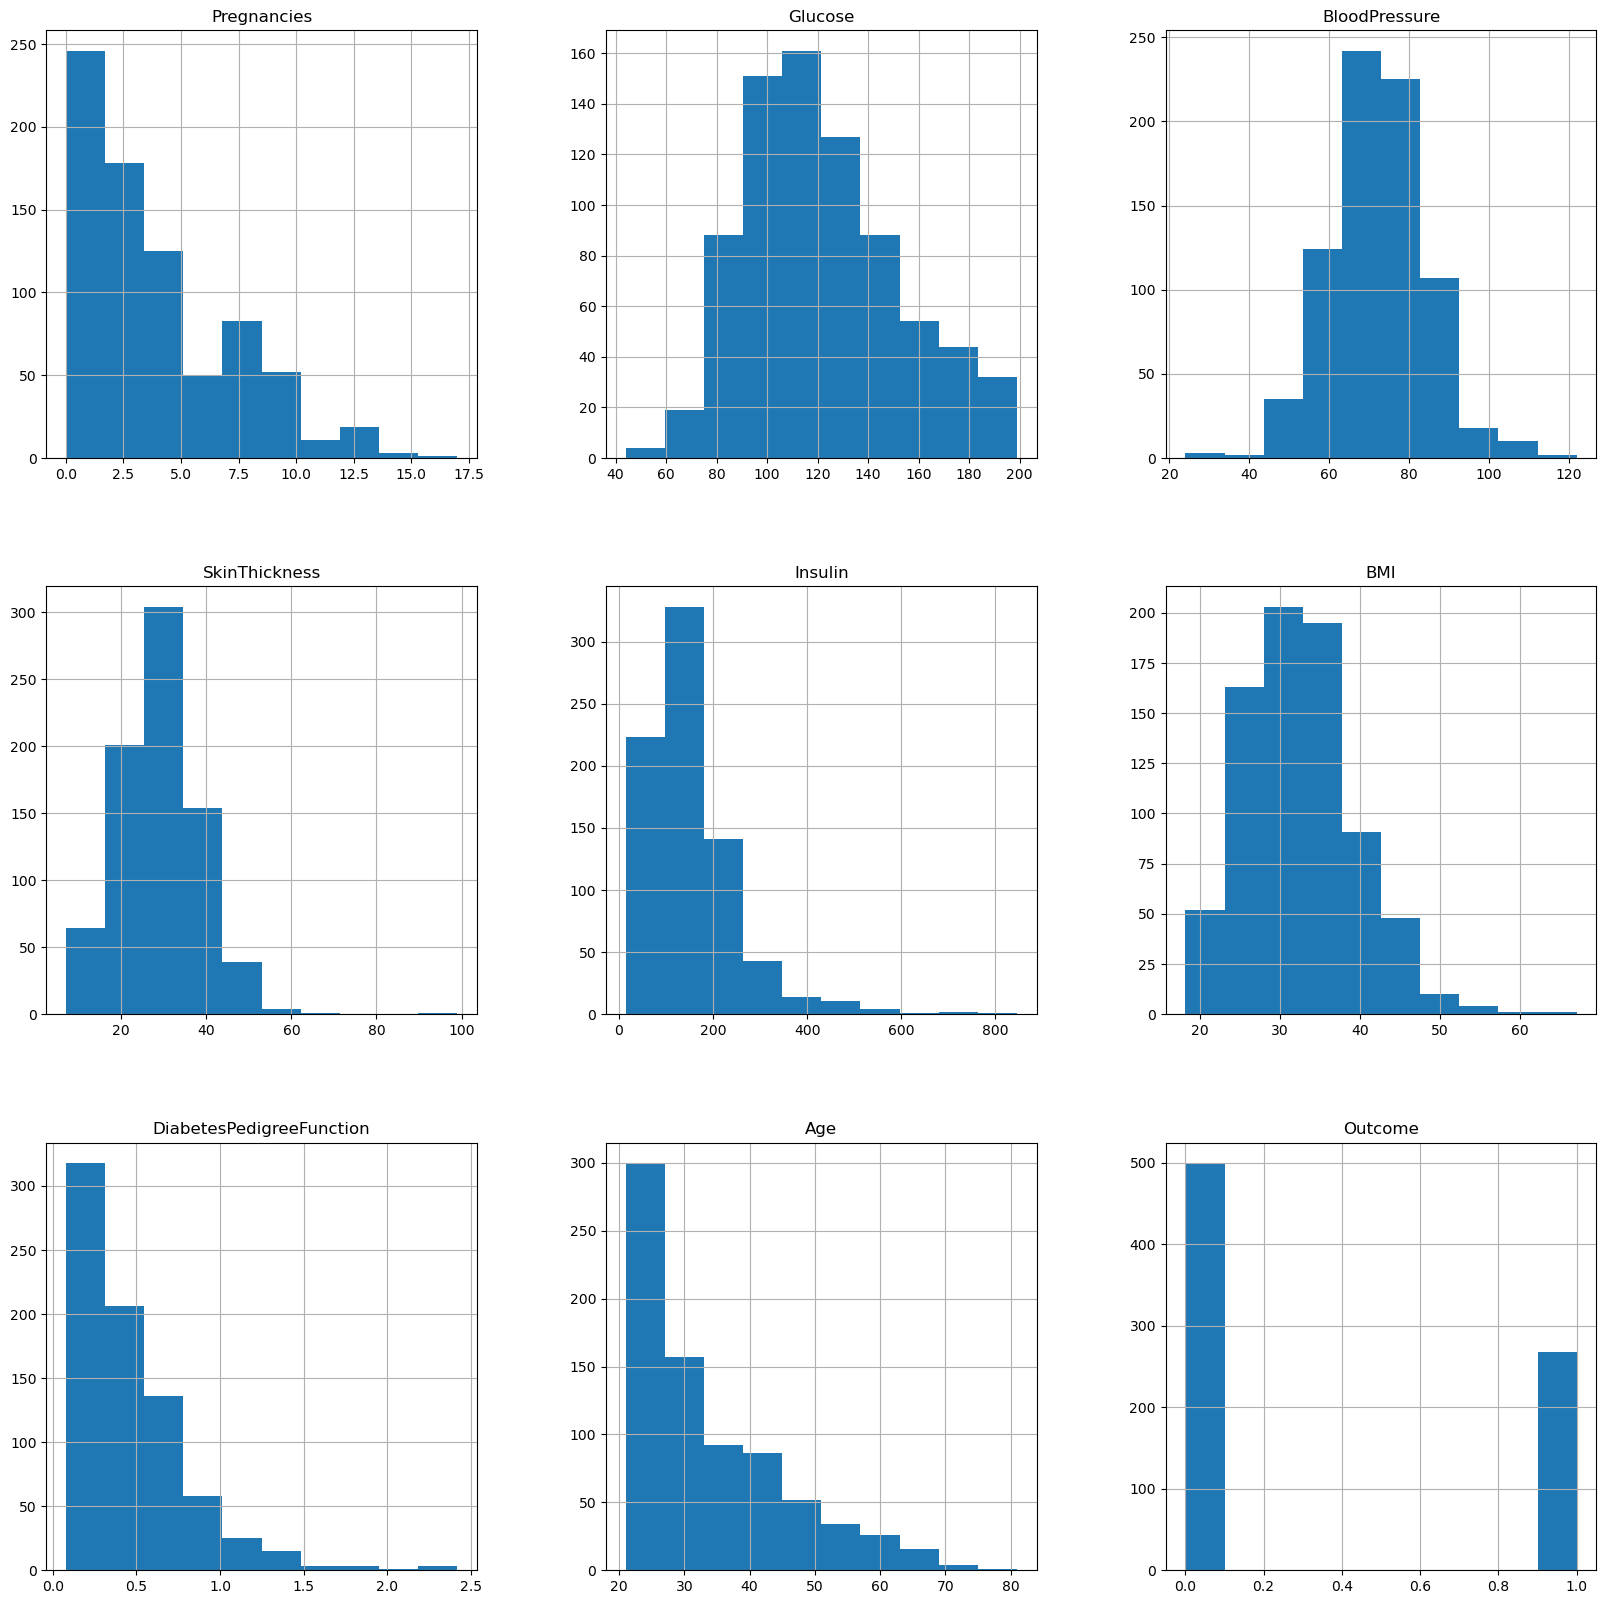

In [72]:
dataset = pd.DataFrame(output, columns=KNN_imputer.get_feature_names_out())  # Transfrom numpy-array 2 pandas-dataframe
print(dataset.describe(), "\n")
print(dataset.info())

p = dataset.hist(figsize = (20,20))
plt.show()

In [73]:
# Outcome is now balanced
print(dataset["Outcome"].value_counts())

feats_X = dataset.iloc[:, [0,1,2,3,4,5,6,7]]
trgt_y = pd.DataFrame(dataset.iloc[:, 8])

Outcome
0.0    500
1.0    268
Name: count, dtype: int64


In [2]:
# Feature Engineering

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction   Age
0          6.0    148.0           72.0           35.0    169.0  33.6                     0.627  50.0
1          1.0     85.0           66.0           29.0     58.6  26.6                     0.351  31.0
2          8.0    183.0           64.0           25.8    164.6  23.3                     0.672  32.0
3          1.0     89.0           66.0           23.0     94.0  28.1                     0.167  21.0
4          0.0    137.0           40.0           35.0    168.0  43.1                     2.288  33.0 

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction   Age
763         10.0    101.0           76.0           48.0    180.0  32.9                     0.171  63.0
764          2.0    122.0           70.0           27.0    165.0  36.8                     0.340  27.0
765          5.0    121.0           72.0           23.0    112.0  26.2             

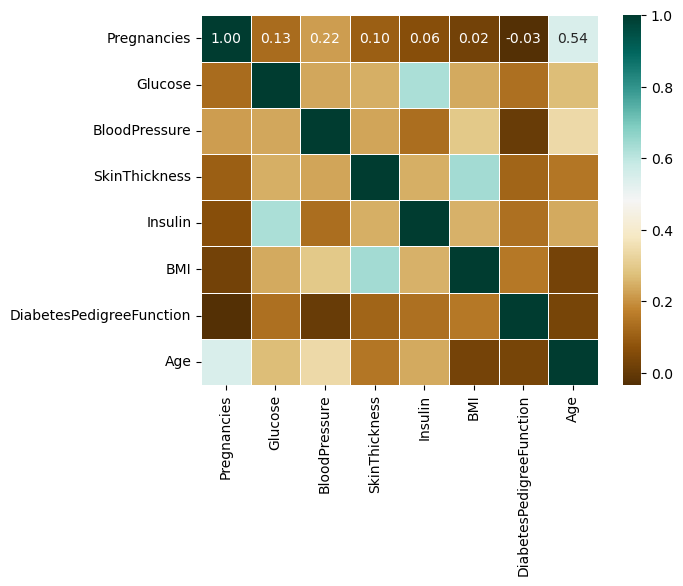

In [74]:
# Feature Engineering -> Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

# Relevant/Good: features(Independent/Input) --high +/-ve correlation--> target(Dependent/Output)
# Irrelevant/Bad: features(Independent/Input) --low near-0 correlation--> target(Dependent/Output)

# 'SelectKBest' Feature-Selection strategy
for t in range(trgt_y.shape[1]):
  KBest = SelectKBest(score_func=f_classif, k= 8)  # Classification(chi2|f_classif|mutual_info_classif); Regression(r_regression|f_regression|mutual_info_regression)
  output = KBest.fit_transform(feats_X, trgt_y.iloc[:,t])  # Fits to data & transform/reduce it to the selected features
  top_feats_X_1 = pd.DataFrame(output, columns=KBest.get_feature_names_out())  # Transfrom numpy-array 2 pandas-dataframe
  print(top_feats_X_1.head(), "\n") #1st 5 rows
  print(top_feats_X_1.tail()) #last 5 rows

sns.heatmap(top_feats_X_1.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BrBG')
plt.show()

In [75]:
# Training & Test Sets: train_test_split
X = top_feats_X_1.loc[:, :]
X = feats_X.loc[:, :]
y = trgt_y  # Using "Outcome" to ensure data(Train|Test) contain fair samples of this feature

print(X.describe())
print(y.describe())
print(X.shape)
print(y.shape, "\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train:", X_train.shape, ",\t", "y_train:", y_train.shape)
print("X_test:", X_test.shape, ",\t", "y_test:", y_test.shape)


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age
count   768.000000  768.000000     768.000000     768.000000  768.000000  768.000000                768.000000  768.000000
mean      3.845052  121.598177      72.371354      29.114583  153.180208   32.427344                  0.471876   33.240885
std       3.369578   30.496543      12.206417       9.424100   98.385308    6.886588                  0.331329   11.760232
min       0.000000   44.000000      24.000000       7.000000   14.000000   18.200000                  0.078000   21.000000
25%       1.000000   99.000000      64.000000      23.000000   87.900000   27.500000                  0.243750   24.000000
50%       3.000000  117.000000      72.000000      29.000000  133.700000   32.090000                  0.372500   29.000000
75%       6.000000  140.250000      80.000000      35.000000  190.150000   36.600000                  0.626250   41.000000
max      17.0000

In [76]:
# Data resampling
from imblearn.over_sampling import SMOTE, SVMSMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN


In [77]:
# Testing SMOTEENN
smoteenn = SMOTEENN(sampling_strategy='not majority')
print("Oversampling minority class... ", end='')
X_train, y_train = smoteenn.fit_resample(X_train, y_train)
print("Done!")

# Testing SMOTE Oversampler
smote = SMOTE(sampling_strategy='not majority', k_neighbors=5)
print("Oversampling minority class... ", end='')
X_train, y_train = smote.fit_resample(X_train, y_train)
print("Done!")


#Testing SVMSMOTE Oversampler
svm_smote = SVMSMOTE(sampling_strategy='not majority', k_neighbors=5)
print("Oversampling minority class... ", end='')
X_train, y_train = svm_smote.fit_resample(X_train, y_train)
print("Done!")

Oversampling minority class... Done!
Oversampling minority class... Done!
Oversampling minority class... Done!


In [3]:
# Data Transformation

In [78]:

# Features' Standardization AND Samples' Normalization ("skewness/unsymmetric" dataset)
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer

# STANDARDIZATION (Column-wise): Non-Linear Transformation for 'feats_X'
# 'QuantileTransformer()' transforms features (columns) with 'skewed/congested' or 'highly-spread' data into a uniform(0..1)/normal(-1..0..+1) distr.
quantile_trans_standzatn = QuantileTransformer(output_distribution='normal')
quantile_trans_standzatn = quantile_trans_standzatn.fit(X_train)  # Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
standized_X_train = quantile_trans_standzatn.transform(X_train)
standized_X_test = quantile_trans_standzatn.transform(X_test)

# STANDARDIZATION (Column-wise): Linear Transformation for 'classifier_y'
# Requires NO transformation for 'trgt_y' cos it already contains values(Binary)
standized_y_train = y_train
standized_y_test = y_test
# Histrogram shows dataset WITHOUT 'skewness' (data is uniformly distributed)
# pd.DataFrame(standized_X_train, columns=X_train.columns).hist(bins=50, figsize=(14, 13))
# plt.show()

"""# compare_models: Trains/evaluates performance of all estimators available in the model library using cross validation.
clf1 = setup(data = dataset,
             target = 'Outcome',
             preprocess = False,
             verbose= False)

top5 = compare_models(sort='AUC',
                      n_select = 5,
                      exclude=['lightgbm','dummy','svm','ridge','qda']
                     )
"""

"# compare_models: Trains/evaluates performance of all estimators available in the model library using cross validation.\nclf1 = setup(data = dataset,\n             target = 'Outcome',\n             preprocess = False,\n             verbose= False)\n\ntop5 = compare_models(sort='AUC',\n                      n_select = 5,\n                      exclude=['lightgbm','dummy','svm','ridge','qda']\n                     )\n"

In [4]:
# Model Training 

In [79]:
# Select ML/DL algorithm AND Tune/Re-tune hyperparameters
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
#from xgboost import XGBClassifier

ml_algorithm = input("Please enter a classifier: ") # KNN, GradBoost, RandFrst, ExtraTree, DeciTree, etc

if (ml_algorithm == "lr"):
  algorithm = MultiOutputClassifier(LogisticRegression(solver='lbfgs'))  # For classification only
elif (ml_algorithm == "lda"):
  algorithm = MultiOutputClassifier(LinearDiscriminantAnalysis())
elif (ml_algorithm == "nb"):
  algorithm = MultiOutputClassifier(GaussianNB())
elif (ml_algorithm == "ada"):
  algorithm = MultiOutputClassifier(AdaBoostClassifier())
elif (ml_algorithm == "gbc"):
  algorithm = MultiOutputClassifier(GradientBoostingClassifier())
# elif (ml_algorithm == "xgboost"):
#   algorithm = MultiOutputClassifier(XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'))
elif (ml_algorithm == "dt"):
  algorithm = MultiOutputClassifier(DecisionTreeClassifier())
elif (ml_algorithm == "rf"):
  algorithm = MultiOutputClassifier(RandomForestClassifier(n_estimators=100))
elif (ml_algorithm == "et"):
  algorithm = MultiOutputClassifier(ExtraTreesClassifier(n_estimators=100))
elif (ml_algorithm == "knn"):
  algorithm = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=6, weights='distance'))
else:
    print("Invalid classifier\nExiting...")
    exit()


In [80]:
# TRAINING: K-Fold Cross-Validation. Fit algorithm(ML) to data(Training).
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef

cv_preds = cross_val_predict(algorithm, standized_X_train, standized_y_train, cv=5, method='predict')
print("Shape of Output/Predictions: ", cv_preds.shape, "\n")
reversed_y_train = pd.DataFrame(cv_preds)
reversed_y_train = np.rint(reversed_y_train).astype(np.int32)

Shape of Output/Predictions:  (512, 1) 



In [5]:
# Model Evaluation

In [81]:
# Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR).
raw_y_train = y_train.values[:,:]
acc = accuracy_score(raw_y_train, reversed_y_train, normalize=True)  # normalize=True(fraction of correctly classified samples); normalize=False(no. of correctly classified samples)
pr_rc_fs_sp = precision_recall_fscore_support(raw_y_train, reversed_y_train, average='weighted')  # average='weighted'(compute metrics per label, and find their avg. weighted by support (no. of true instances per label))
mcc = matthews_corrcoef(raw_y_train, reversed_y_train)
algorithm.fit(standized_X_train, standized_y_train)
pred_scr = algorithm.predict_proba(standized_X_train)[0]
roc = roc_auc_score(raw_y_train, pred_scr[:,1], average='weighted', multi_class='ovo')  # multi_class='ovo'(meaning One-vs-one. Computes avg. AUC of all possible pairwise combinations of classes)


In [82]:
# Training Metrics
print("Training Metrics: ", "\n----------------")
print("ACCURACY: ", acc)
print("PRECISION: ", pr_rc_fs_sp[0])
print("RECALL: ", pr_rc_fs_sp[1])
print("F1-SCORE: ", pr_rc_fs_sp[2])
print("AREA under ROC: ", roc)
print("MCC: ", mcc)

Training Metrics:  
----------------
ACCURACY:  0.8984375
PRECISION:  0.9008843036109064
RECALL:  0.8984375
F1-SCORE:  0.8982822910935877
AREA under ROC:  0.9647216796875
MCC:  0.7993180586474211


In [6]:
# Model Testing 


In [83]:
# TESTING/GENERALIZATION: Make Predictions for 'y-component' wrt. data(Test)
model = algorithm
model.fit(standized_X_train, standized_y_train)
pred_y_test = model.predict(standized_X_test)
reversed_y_test = pd.DataFrame(pred_y_test)
reversed_y_test = np.rint(reversed_y_test).astype(np.int32)

In [84]:
# Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR).
raw_y_test = y_test.values[:,:]
acc = accuracy_score(raw_y_test, reversed_y_test, normalize=True)  # normalize=True(fraction of correctly classified samples); normalize=False(no. of correctly classified samples)
pr_rc_fs_sp = precision_recall_fscore_support(raw_y_test, reversed_y_test, average='weighted')  # average='weighted'(compute metrics per label, and find their avg. weighted by support (no. of true instances per label))
mcc = matthews_corrcoef(raw_y_test, reversed_y_test)
pred_scr = model.predict_proba(standized_X_test)[0]
roc = roc_auc_score(raw_y_test, pred_scr[:,1], average='weighted', multi_class='ovo')  # multi_class='ovo'(meaning One-vs-one. Computes avg. AUC of all possible pairwise combinations of classes)


In [85]:
# Testing Metrics
print("\nTesting Metrics: ", "\n----------------")
print("ACCURACY: ", acc)
print("PRECISION: ", pr_rc_fs_sp[0])
print("RECALL: ", pr_rc_fs_sp[1])
print("F1-SCORE: ", pr_rc_fs_sp[2])
print("AREA under ROC: ", roc)
print("MCC: ", mcc)



Testing Metrics:  
----------------
ACCURACY:  0.6948051948051948
PRECISION:  0.7638267955403505
RECALL:  0.6948051948051948
F1-SCORE:  0.7008464695238352
AREA under ROC:  0.8024074074074075
MCC:  0.4431651095533223


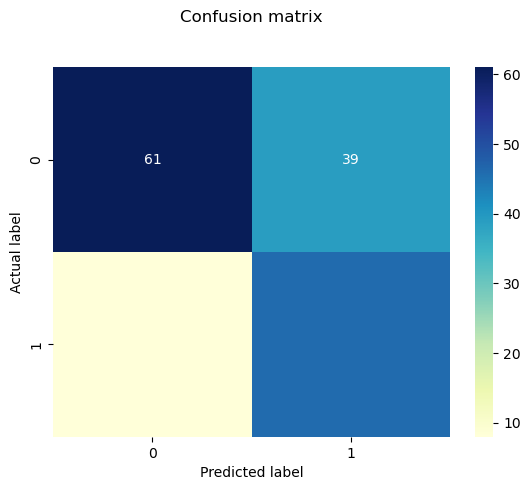

In [86]:
cnf_matrix = metrics.confusion_matrix(y_test, pred_y_test)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


In [87]:
scores = cross_val_score(algorithm, standized_X_train, standized_y_train, cv=3)
print("%20s | Accuracy: %0.2f%% (+/- %0.2f%%)" % (ml_algorithm, 100*scores.mean(), 100*scores.std() * 2))

                  nb | Accuracy: 89.26% (+/- 4.27%)


In [ ]:
# model evaluation done , deployin it using FastAPI as a web API

In [93]:
#making the predictive system
input_data  = (8,183,64,0,0,23.3,0.672,32)
input_data_as_np_array = np.asarray(input_data)
input_data_reshaped = input_data_as_np_array.reshape(1,-1)
prediction = algorithm.predict(input_data_reshaped)
print(prediction)
if(prediction[0]==0):
    print('This person is not diabetic')
else:
    print("The person is diabetic")


[[1.]]
The person is diabetic


In [7]:
# saving the model as pickle file so that is can be used to develop a web application.

In [90]:
import pickle

In [91]:
 filename = 'diabetes_model_nb.sav'
 pickle.dump(algorithm,open(filename,'wb'))